# Figure 2 — SWE-bench Verified: GLM-5.2 vs Kimi-K3 vs Claude Opus 5

This notebook reproduces the three-model domain comparison from the recorded, corrected n=150 results. Every model is scored against the same stratified pool using the `resolved_ids` from its official SWE-bench summary.

Domain labels are deterministic mappings from each SWE-bench instance's repository prefix. Each of the five domains contains 30 tasks.

In [1]:
# Install missing packages into the active kernel, including uv environments without pip.
import importlib.util
import shutil
import subprocess
import sys

required = {'matplotlib': 'matplotlib>=3.9', 'pandas': 'pandas>=2.2'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    print(f'Installing missing packages into {sys.executable}: {", ".join(missing)}')
    if uv := shutil.which('uv'):
        subprocess.check_call([uv, 'pip', 'install', '--python', sys.executable, *missing])
    else:
        if importlib.util.find_spec('pip') is None:
            subprocess.check_call([sys.executable, '-m', 'ensurepip', '--upgrade'])
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
else:
    print('Notebook dependencies are already available in this kernel.')

Notebook dependencies are already available in this kernel.


In [2]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

def find_repo(start):
    for candidate in (start, *start.parents):
        if (candidate / 'results/swe-bench-verified/2026-07-regraded').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the agent-benchmark repository.')

REPO = find_repo(Path.cwd().resolve())
BUNDLE = REPO / 'results/swe-bench-verified/2026-07-regraded'
POOL_PATH = BUNDLE / 'audit/pool_stratified_n150.json'

MODELS = {
    'GLM-5.2 xhigh': {
        'summary': BUNDLE / 'results/glm-5.2/xhigh_n150/official_summary.json',
        'color': '#2a78d6',
    },
    'Kimi-K3 max': {
        'summary': BUNDLE / 'results/kimi-k3/max_n150/official_summary.json',
        'color': '#eb6834',
    },
    'Claude Opus 5 max': {
        'summary': BUNDLE / 'results/claude-opus-5/max_n150/official_summary.json',
        'color': '#1baf7a',
    },
}

PREFIX_TO_DOMAIN = {
    'sympy': 'Symbolic math',
    'sphinx-doc': 'Dev tooling', 'pytest-dev': 'Dev tooling', 'pylint-dev': 'Dev tooling',
    'scikit-learn': 'Scientific & data', 'astropy': 'Scientific & data',
    'pydata': 'Scientific & data',
    'matplotlib': 'Data-viz', 'mwaskom': 'Data-viz',
    'django': 'Web & HTTP', 'psf': 'Web & HTTP', 'pallets': 'Web & HTTP',
}

Matplotlib is building the font cache; this may take a moment.


## Recompute official scores by domain

The denominator comes only from the shared pool. A task counts as solved only when its ID appears in that model's official `resolved_ids`.

In [3]:
pool = json.loads(POOL_PATH.read_text())['instance_ids']
assert len(pool) == 150 and len(set(pool)) == 150

def load_resolved(path):
    summary = json.loads(path.read_text())
    resolved = summary.get('resolved_ids')
    if not isinstance(resolved, list):
        raise ValueError(f'No resolved_ids list in {path}')
    assert summary['total_instances'] == len(pool)
    assert summary['resolved_instances'] == len(resolved)
    return set(resolved), summary

def score_by_domain(resolved):
    counts = defaultdict(lambda: {'resolved': 0, 'total': 0})
    for instance_id in pool:
        prefix = instance_id.split('__', 1)[0]
        domain = PREFIX_TO_DOMAIN[prefix]
        counts[domain]['total'] += 1
        counts[domain]['resolved'] += instance_id in resolved
    return counts

rows = []
overall_rows = []
for model, config in MODELS.items():
    resolved, summary = load_resolved(config['summary'])
    scores = score_by_domain(resolved)
    for domain, score in scores.items():
        rows.append({
            'model': model, 'domain': domain, **score,
            'rate_pct': 100 * score['resolved'] / score['total'],
        })
    overall_rows.append({
        'model': model, 'resolved': summary['resolved_instances'],
        'total': summary['total_instances'],
        'rate_pct': 100 * summary['resolved_instances'] / summary['total_instances'],
    })

scores = pd.DataFrame(rows)
overall = pd.DataFrame(overall_rows).set_index('model')
assert set(scores.groupby('domain').total.unique().map(tuple)) == {(30,)}
overall.style.format({'rate_pct': '{:.1f}%'})

,resolved,total,rate_pct
model,,,
GLM-5.2 xhigh,123,150,82.0%
Kimi-K3 max,145,150,96.7%
Claude Opus 5 max,149,150,99.3%


In [4]:
score_labels = scores.assign(
    score=scores.apply(lambda row: f"{row.rate_pct:.1f}% ({row.resolved}/{row.total})", axis=1)
).pivot(index='domain', columns='model', values='score')
score_labels[list(MODELS)]

model,GLM-5.2 xhigh,Kimi-K3 max,Claude Opus 5 max
domain,,,
Data-viz,83.3% (25/30),96.7% (29/30),100.0% (30/30)
Dev tooling,76.7% (23/30),96.7% (29/30),100.0% (30/30)
Scientific & data,76.7% (23/30),93.3% (28/30),96.7% (29/30)
Symbolic math,80.0% (24/30),100.0% (30/30),100.0% (30/30)
Web & HTTP,93.3% (28/30),96.7% (29/30),100.0% (30/30)


## Figure 2 — grouped domain comparison

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/fig2_swebench_verified_domain_compare.png


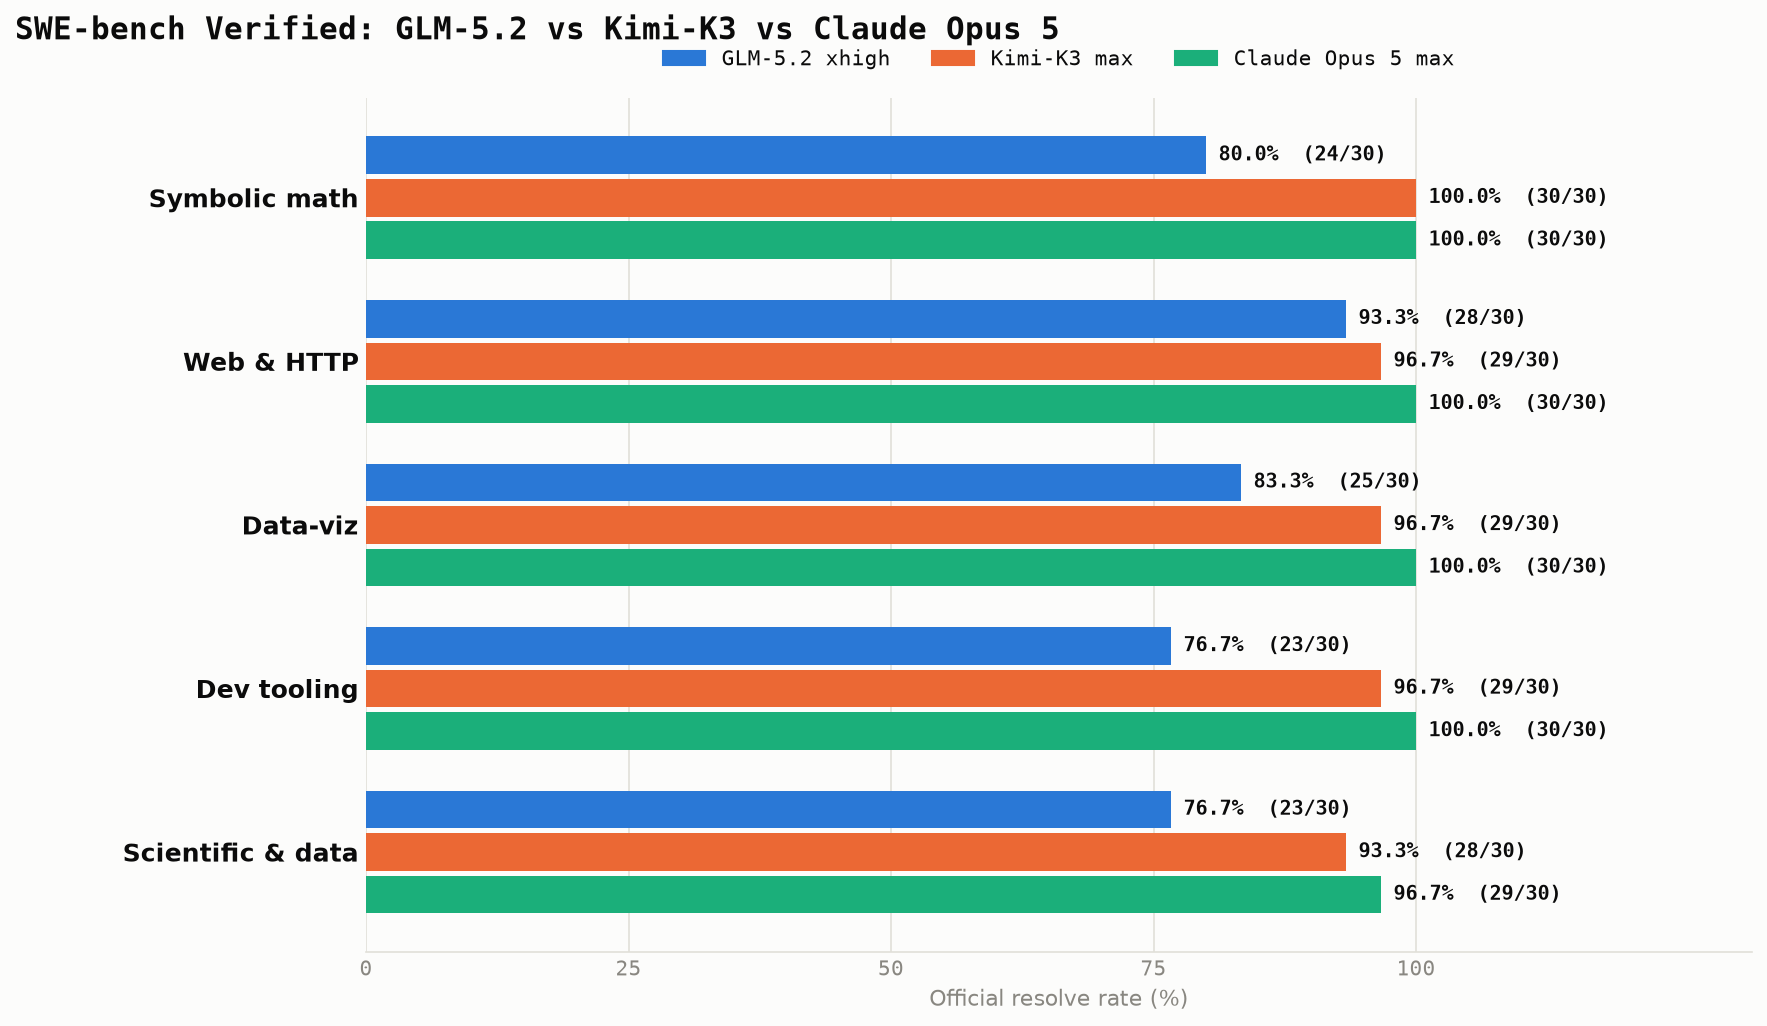

In [5]:
SURFACE = '#fcfcfb'; INK = '#0b0b0b'; MUTED = '#898781'; GRID = '#e1e0d9'
MONO = ['DejaVu Sans Mono', 'Menlo', 'monospace']

# Preserve the original Figure 2 top-to-bottom ordering. barh draws the first item at the bottom.
domains = ['Scientific & data', 'Dev tooling', 'Data-viz', 'Web & HTTP', 'Symbolic math']
fig, ax = plt.subplots(figsize=(12, 7.4), dpi=150)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)

height = 0.26
offsets = [height, 0.0, -height]
for yi, domain in enumerate(domains):
    for (model, config), offset in zip(MODELS.items(), offsets):
        row = scores[(scores.model == model) & (scores.domain == domain)].iloc[0]
        ax.barh(yi + offset, row.rate_pct, height=height - 0.03, color=config['color'], zorder=3)
        ax.text(row.rate_pct + 1.2, yi + offset,
                f'{row.rate_pct:.1f}%  ({row.resolved}/{row.total})',
                va='center', ha='left', fontsize=9.5, color=INK,
                fontfamily=MONO, fontweight='bold')

ax.set_yticks(range(len(domains)))
ax.set_yticklabels(domains, fontsize=12, fontweight='bold', color=INK)
ax.set_xlim(0, 132); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0', '25', '50', '75', '100'], fontsize=10, color=MUTED, fontfamily=MONO)
ax.set_xlabel('Official resolve rate (%)', fontsize=10.5, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'): ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color(GRID); ax.tick_params(length=0)
ax.legend(handles=[Patch(color=config['color'], label=model) for model, config in MODELS.items()],
          loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3,
          frameon=False, fontsize=11, prop={'family': MONO}, labelcolor=INK)
fig.text(0.005, 0.955, 'SWE-bench Verified: GLM-5.2 vs Kimi-K3 vs Claude Opus 5',
         fontsize=15, fontweight='bold', fontfamily=MONO, color=INK, va='top')
fig.subplots_adjust(left=0.20, right=0.97, top=0.88, bottom=0.11)

out = REPO / 'notebooks/fig2_swebench_verified_domain_compare.png'
fig.savefig(out, facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()